# 01 — Pricing Method Comparison

Compare the four pricing methods — **Black-Scholes**, **Monte Carlo**, **Binomial (CRR)**, and **Crank-Nicolson** — on the reference contract `OptionParams(S=100, K=100, T=1, r=0.05, σ=0.2)`.


In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from pricer.models import OptionParams
from pricer.black_scholes import price as bs_price
from pricer import monte_carlo as mc
from pricer import binomial
from pricer import finite_difference as fd

REF = OptionParams(S=100, K=100, T=1.0, r=0.05, sigma=0.2)
ATM_BS = bs_price(REF, 'call')
print(f"BS reference call price: {ATM_BS:.4f}")


BS reference call price: 10.4506


## 1. Single-price comparison

In [2]:
results = {
    'Black-Scholes':      ATM_BS,
    'Binomial (N=500)':   binomial.price(REF, 'call', n=500),
    'Crank-Nicolson':     fd.price(REF, 'call', m=200, n=200),
    'Monte Carlo (500k)': mc.price(REF, 'call', n=500_000, seed=42)['price'],
}

df_compare = pd.DataFrame(
    [(k, v, abs(v - ATM_BS)) for k, v in results.items()],
    columns=['Method', 'Price', '|Error vs BS|']
).set_index('Method')
df_compare['Price'] = df_compare['Price'].map('{:.6f}'.format)
df_compare['|Error vs BS|'] = df_compare['|Error vs BS|'].map('{:.2e}'.format)
print(df_compare.to_string())


                        Price |Error vs BS|
Method                                     
Black-Scholes       10.450584      0.00e+00
Binomial (N=500)    10.446585      4.00e-03
Crank-Nicolson      10.452638      2.05e-03
Monte Carlo (500k)  10.456280      5.70e-03


## 2. Convergence: Binomial tree depth

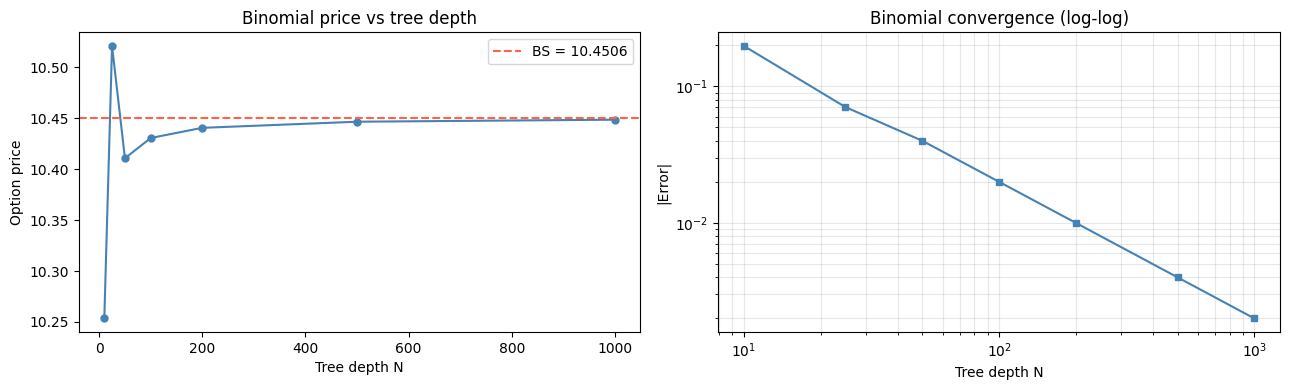

In [3]:
rows = binomial.convergence(REF, step_sizes=[10,25,50,100,200,500,1000])
df_bin = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(df_bin['n'], df_bin['price'], 'o-', color='steelblue', ms=5)
ax.axhline(ATM_BS, color='tomato', ls='--', lw=1.5, label=f'BS = {ATM_BS:.4f}')
ax.set_xlabel('Tree depth N')
ax.set_ylabel('Option price')
ax.set_title('Binomial price vs tree depth')
ax.legend()

ax = axes[1]
ax.loglog(df_bin['n'], df_bin['error'], 's-', color='steelblue', ms=5)
ax.set_xlabel('Tree depth N')
ax.set_ylabel('|Error|')
ax.set_title('Binomial convergence (log-log)')
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/binomial_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Convergence: Crank-Nicolson grid refinement

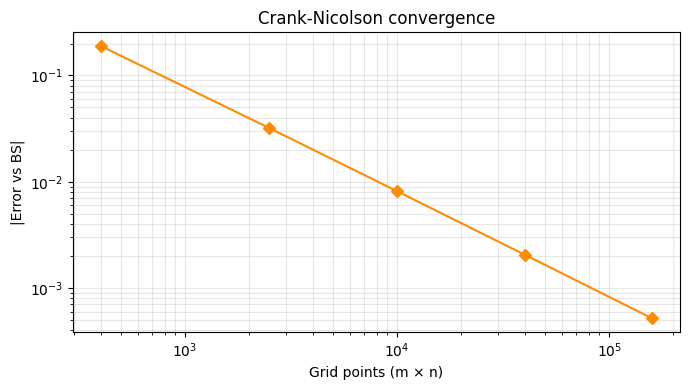

In [4]:
grid_sizes = [(20,20),(50,50),(100,100),(200,200),(400,400)]
rows_fd = fd.convergence(REF, grid_sizes=grid_sizes)
df_fd = pd.DataFrame(rows_fd)
df_fd['dof'] = df_fd['m'] * df_fd['n']

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(df_fd['dof'], df_fd['error'], 'D-', color='darkorange', ms=6)
ax.set_xlabel('Grid points (m × n)')
ax.set_ylabel('|Error vs BS|')
ax.set_title('Crank-Nicolson convergence')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/cn_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Monte Carlo convergence with confidence intervals

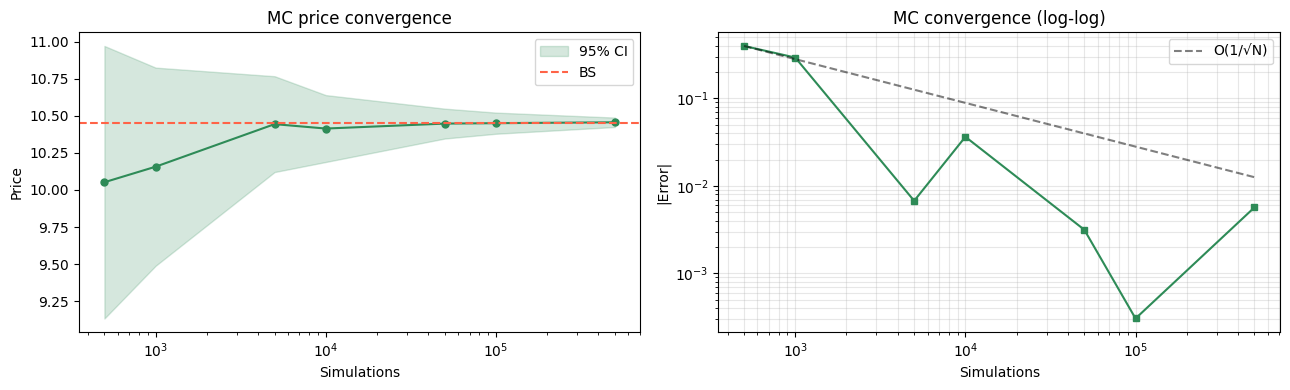

In [5]:
mc_rows = mc.convergence(REF, sample_sizes=[500,1000,5000,10000,50000,100000,500000])
df_mc = pd.DataFrame(mc_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.semilogx(df_mc['n'], df_mc['price'], 'o-', color='seagreen', ms=5)
ax.fill_between(df_mc['n'], df_mc['ci_low'], df_mc['ci_high'],
                alpha=0.2, color='seagreen', label='95% CI')
ax.axhline(ATM_BS, color='tomato', ls='--', lw=1.5, label='BS')
ax.set_xlabel('Simulations')
ax.set_ylabel('Price')
ax.set_title('MC price convergence')
ax.legend()

ax = axes[1]
ax.loglog(df_mc['n'], df_mc['error'], 's-', color='seagreen', ms=5)
ns = np.array(df_mc['n'])
ax.loglog(ns, df_mc['error'].iloc[0] * np.sqrt(ns[0]/ns), 'k--',
          alpha=0.5, label='O(1/√N)')
ax.set_xlabel('Simulations')
ax.set_ylabel('|Error|')
ax.set_title('MC convergence (log-log)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/mc_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Price vs strike — all methods

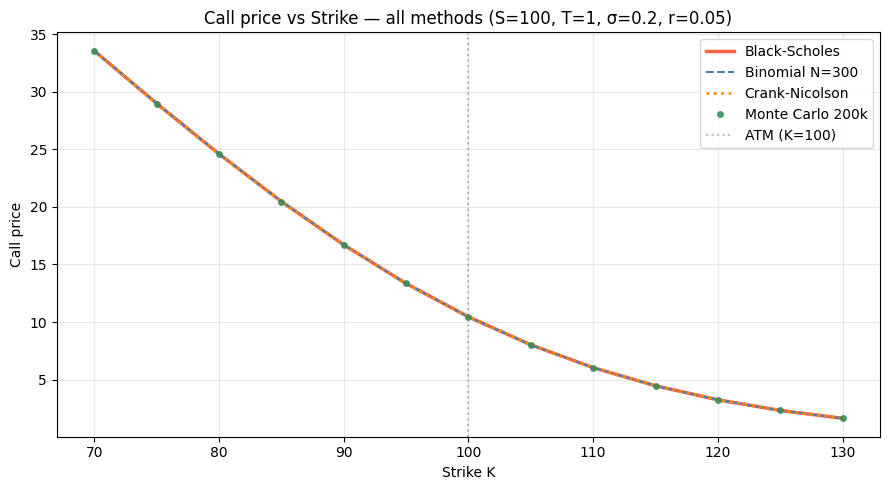

In [6]:
strikes = np.arange(70, 135, 5)
bs_prices, bin_prices, fd_prices, mc_prices = [], [], [], []
for K in strikes:
    p = OptionParams(S=100, K=K, T=1.0, r=0.05, sigma=0.2)
    bs_prices.append(bs_price(p, 'call'))
    bin_prices.append(binomial.price(p, 'call', n=300))
    fd_prices.append(fd.price(p, 'call', m=150, n=150))
    mc_prices.append(mc.price(p, 'call', n=200_000, seed=0)['price'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(strikes, bs_prices,  '-',  lw=2.5, label='Black-Scholes', color='tomato')
ax.plot(strikes, bin_prices, '--', lw=1.5, label='Binomial N=300', color='steelblue')
ax.plot(strikes, fd_prices,  ':',  lw=2,   label='Crank-Nicolson', color='darkorange')
ax.plot(strikes, mc_prices,  'o',  ms=4,   label='Monte Carlo 200k', color='seagreen', alpha=0.8)
ax.axvline(100, color='grey', ls=':', alpha=0.5, label='ATM (K=100)')
ax.set_xlabel('Strike K')
ax.set_ylabel('Call price')
ax.set_title('Call price vs Strike — all methods (S=100, T=1, σ=0.2, r=0.05)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/price_vs_strike.png', dpi=150, bbox_inches='tight')
plt.show()
